In [1]:
from monai.transforms import Compose, LoadImage, EnsureChannelFirst
from matplotlib.patches import Patch
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from pathlib import PureWindowsPath
import os
import ipywidgets as widgets



## Data Analysis

In [15]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/dataset-registration-artinet.csv")
data.head(10)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SubjectKeyRadiology                 5572 non-null   str    
 1   ExamDate                            5572 non-null   str    
 2   SegmentationBatch                   5572 non-null   str    
 3   NiiFile                             5572 non-null   str    
 4   SegNiiFile                          5572 non-null   str    
 5   file                                5572 non-null   str    
 6   is_liver_imaged                     5572 non-null   str    
 7   contrast                            5454 non-null   str    
 8   phase_timing                        5454 non-null   str    
 9   is_lesionfree                       5572 non-null   str    
 10  ai_segmentation_quality             3498 non-null   float64
 11  manual_segmentation_confidence      3498 non-null   fl

In [16]:
data.dropna(axis=0, how='all')
data = data.drop(columns=['other', 'comment', 'RawImage'])
data.dropna(subset=["contrast"], inplace=True, ignore_index=True)  # 118 entries with unknown phase removed
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5454 entries, 0 to 5453
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SubjectKeyRadiology                 5454 non-null   str    
 1   ExamDate                            5454 non-null   str    
 2   SegmentationBatch                   5454 non-null   str    
 3   NiiFile                             5454 non-null   str    
 4   SegNiiFile                          5454 non-null   str    
 5   file                                5454 non-null   str    
 6   is_liver_imaged                     5454 non-null   str    
 7   contrast                            5454 non-null   str    
 8   phase_timing                        5454 non-null   str    
 9   is_lesionfree                       5454 non-null   str    
 10  ai_segmentation_quality             3498 non-null   float64
 11  manual_segmentation_confidence      3498 non-null   fl

### Reformatting

In [17]:
data['AcquisitionTime']

0       10:31.7
1       03:19.6
2       30:13.3
3       19:47.1
4       27:10.0
         ...   
5449    13:16.1
5450    05:45.6
5451    06:20.1
5452    43:20.6
5453    43:50.0
Name: AcquisitionTime, Length: 5454, dtype: str

In [18]:
data["ExamDate"] = pd.to_datetime(data["ExamDate"])

In [19]:
data.BodyPartExamined.value_counts()

BodyPartExamined
ABDOMEN             3831
CHEST                100
CT_ABD C_ MET VO       4
CT BBUIK ZMK           4
BUIK                   4
THORAX                 3
CT ABDOMEN             2
CT THORAX_ABD___       2
CT ABDOMEN MULTI       1
CT_ABD C_ZONDER        1
CT LEVER 3_F           1
CT HALS_THORA___       1
CT ABD C_ MET VB       1
_S_297                 1
NECK                   1
CHEST _ ABDOMEN        1
CT THORAX EN ___       1
Name: count, dtype: int64

In [21]:
data[data.BodyPartExamined.isna()]['ProtocolName'].value_counts()

ProtocolName
ABDOMEN + C 1.0 FC01        443
ABDOMEN A 1.0 FC01          406
ABDOMEN + C 1.0 FC02        186
ABDOMEN A 1.0 FC02          157
LEVER A 1.0 FC01             59
Abdomen A 2mm                30
Abdomen V 2mm                30
Body 1.0 CE   Vol.           30
Abdomen 2mm                  27
Lever A 2mm                  25
Abdomen +C 2mm               23
LEVER A 1.0 FC12              9
Mediastinum 2mm               7
LEVER A 1.0 FC02              7
2MM PORTAAL                   6
LEVER -C 1.0 FC07             4
MEDIASTINUM +C 1.0 FC02       4
PORTAAL 3MM.                  3
Lever +C 2mm                  3
1.0 FC01                      2
PANCREAS 2MM.                 2
Sharp + C 2 mm                2
LEVER -C 1.0 FC12             2
LEVER A 1.0 FC03              2
Thorax- buik 2mm              2
SOFT TISSUE 1.0 CE            2
OMC PANCREAS VEN              1
Abd. PV 3.0                   1
ABDOMEN+ th + C 1.0 FC01      1
lever -C 2mm                  1
Lever -C 2mm               

In [22]:
mask = data['BodyPartExamined'].isna()

# extract first word from ProtocolName
first_word = (
    data.loc[mask, 'ProtocolName']
    .astype(str)
    .str.strip()
    .str.split()
    .str[0]
    .str.upper()
)

# allowed mappings
mapping = {
    'PANCREAS': 'PANCREAS',
    'SOFT': 'SOFT TISSUE',
    'ABDOMEN': 'ABDOMEN',
    'ABDOMEN+': 'ABDOMEN',
    'Abdomen': 'ABDOMEN',
    'Abd.': 'ABDOMEN',
    'Lever': 'LEVER',
    'LEVER': 'LEVER',
    'lever': 'LEVER',
    'BODY': 'BODY',
    'Body': 'BODY',
    'Mediastinum': 'MEDIASTINUM',
    'MEDIASTINUM': 'MEDIASTINUM'
}

# fill only if first word is in mapping
data.loc[mask, 'BodyPartExamined'] = first_word.map(mapping)

In [27]:
data['BodyPartExamined'].value_counts()

BodyPartExamined
ABDOMEN             5136
LEVER                113
CHEST                100
BODY                  31
MEDIASTINUM           11
CT_ABD C_ MET VO       4
CT BBUIK ZMK           4
BUIK                   4
PANCREAS               3
THORAX                 3
CT ABDOMEN             2
CT THORAX_ABD___       2
SOFT TISSUE            2
CT ABDOMEN MULTI       1
CT_ABD C_ZONDER        1
CT LEVER 3_F           1
CT HALS_THORA___       1
CT ABD C_ MET VB       1
_S_297                 1
NECK                   1
CHEST _ ABDOMEN        1
CT THORAX EN ___       1
Name: count, dtype: int64

In [26]:
int(data['BodyPartExamined'].isna().sum())

30

In [28]:
# Replace commas with dots in numbers
data['ProtocolName'] = data['ProtocolName'].str.replace(r'(\d+),(\d+)', r'\1.\2', regex=True)

print(data.ProtocolName.value_counts())

data['slice_thickness'] = (
    data['ProtocolName']
    .str.extract(r'(\d+\.\d+|\d+(?=\s*[mM]{2}))')
    .astype(float)
)

data.slice_thickness.value_counts()

ProtocolName
Body 1.0 CE   Vol.             1194
Abdomen A  1.5  B25f            776
Abdomen V  1.5  B25f            681
ABDOMEN + C 1.0 FC01            443
ABDOMEN A 1.0 FC01              406
                               ... 
ven Abdomen  3.0  I30f  3         1
D70 Abd. alg.  3.0  B31f          1
Abd  ThorAbd  1.0  Br40  3        1
Arterieel CTA 2.0 CE Axial        1
ThoraxAbd ax.  3.0  Bf37  2       1
Name: count, Length: 226, dtype: int64


slice_thickness
1.0    2977
1.5    2030
3.0     264
2.0     172
Name: count, dtype: int64

In [29]:
data[data['slice_thickness'] == 2.0 ][['ProtocolName', 'slice_thickness']]

,ProtocolName,slice_thickness
9,Mediastinum 2mm,2.0
29,Mediastinum 2mm,2.0
49,Abdomen A 2mm,2.0
57,Abdomen V 2mm,2.0
67,Mediastinum 2mm,2.0
...,...,...
4655,Abdomen V 2mm,2.0
4656,Lever A 2mm,2.0
4720,Lever A 2mm,2.0
5346,Abdomen 2mm,2.0


In [31]:
def map_phase(protocol_name):
    protocol_name = str(protocol_name).lower()  # normalize
    if any(k in protocol_name for k in ['a ', ' art', ' art.', 'arterieel']):
        return 'Arterial'
    elif any(k in protocol_name for k in ['p ', ' pv ',' v ', 'portaal', 'venous', 'veneus', 'ven', 'port']):
        return 'Portal'
    elif any(k in protocol_name for k in ['late fase', 'delayed phase']):
        return 'Late phase'
    elif any(k in protocol_name for k in [' laat-']):
        return 'Late arterial'
    else:
        return np.nan  # unknown / other

# Apply mapping
data['DICOM_phase'] = data['ProtocolName'].apply(map_phase)

In [32]:
data[data.slice_thickness.isna()][['ProtocolName', 'DICOM_phase', 'slice_thickness']]

,ProtocolName,DICOM_phase,slice_thickness
10,OMC PANCREAS VEN,Portal,NaN
1662,PANCREAS,NaN,NaN
1713,D240,NaN,NaN
1823,LATE FASE,Late phase,NaN
2041,PTD 10 SEC,NaN,NaN
2042,PTD 70 SEC.,NaN,NaN
3237,A 30,Arterial,NaN
3310,TS_AX port,Portal,NaN
3727,PTD 10 sec,NaN,NaN
3728,PTD 70 sec,NaN,NaN


In [33]:
data[['ProtocolName', 'DICOM_phase', 'slice_thickness']]

,ProtocolName,DICOM_phase,slice_thickness
0,ABDOMEN A 1.0 FC02,Arterial,1.0
1,ABDOMEN + C 1.0 FC01,NaN,1.0
2,Maag.abdomen 1.5 B30f,NaN,1.5
3,Abdomen V 1.5 B25f,Portal,1.5
4,Abdomen V 1.5 B25f,Portal,1.5
...,...,...,...
5449,Abdomen V 1.5 B25f,Portal,1.5
5450,Abd laat-art 1.0 Bv38 2,Late arterial,1.0
5451,Abdomen 1.0 Bv38 2,NaN,1.0
5452,Abd laat-art 1.0 Bv38 2,Late arterial,1.0


In [ ]:
# no_phase = data[data.DICOM_phase.isna()][['ProtocolName', 'DICOM_phase', 'slice_thickness']]

# list(np.unique(no_phase.ProtocolName))

['1 - THOR.+C. 3.0 B30f',
 '1.0 FC01',
 '2 - ABD.+C. 3.0 B30f',
 '2MM MEDIASTINUM',
 'ABDOMEN + C 1.0 FC01',
 'ABDOMEN + C 1.0 FC02',
 'ABDOMEN 3 MM',
 'ABDOMEN+ th + C 1.0 FC01',
 'Abd  ThorAbd  1.0  Br40  3',
 'Abd Routine  1.5  I31f sv ax',
 'Abd Routine  3.0  I31f  3',
 'Abd Routine  3.0  I31f  ax',
 'Abd-Contrast  3.0  B40f',
 'Abd-Contrast  3.0  I40f  2',
 'Abd-Contrast 3.0 B30f',
 'Abd. VV  2.0  B30f',
 'Abd.Routine  3.0  B30f',
 'AbdRoutine 3.0 B30s',
 'Abd_Routine  1.5  I31f  3 sv ax',
 'Abd_Routine  3.0  I31f  3 ax',
 'Abdomen   1.5  B30f',
 'Abdomen  1.0  Bf37  2 iMAR',
 'Abdomen  1.0  Bv38  2',
 'Abdomen  1.0  I26f  2',
 'Abdomen  1.0  I26f  2   iMAR',
 'Abdomen  1.0  I30f  3',
 'Abdomen  1.5  B25f',
 'Abdomen  1.5  B30f',
 'Abdomen  3.0  B31f',
 'Abdomen  3.0  I30f  3',
 'Abdomen  3.0  I31f  3',
 'Abdomen +C  1.5  B25f',
 'Abdomen +C  1.5  B30f',
 'Abdomen +C  3.0  B31f',
 'Abdomen +C 2mm',
 'Abdomen 1.0 Contrast CE',
 'Abdomen 2mm',
 'Abdomen 3mm  3.0  B30f',
 'Abdomen BB

In [34]:
data.DICOM_phase.value_counts()

DICOM_phase
Arterial         1752
Portal            899
Late arterial     169
Late phase          3
Name: count, dtype: int64

### Duplicates

In [35]:
contrast_conflicts = (
    data
    .groupby([
        'SubjectKeyRadiology',
        'ExamDate',
        'AcquisitionTime',
        'ConvolutionKernel'
    ])['contrast']
    .nunique()
    .reset_index()
)

# Keep only cases where contrast differs
contrast_conflicts = contrast_conflicts[contrast_conflicts['contrast'] > 1]

print("Cases with different contrast phases due to reconstruction differences:", len(contrast_conflicts))

timing_conflicts = (
    data
    .groupby([
        'SubjectKeyRadiology',
        'ExamDate',
        'AcquisitionTime',
        'ConvolutionKernel'
    ])['phase_timing']
    .nunique()
    .reset_index()
)

# Keep only cases where contrast differs
timing_conflicts = timing_conflicts[timing_conflicts['phase_timing'] > 1]

print("Cases with different phase timings due to reconstruction differences:", len(timing_conflicts))

Cases with different contrast phases due to reconstruction differences: 0
Cases with different phase timings due to reconstruction differences: 1


In [36]:
timing_conflicts

,SubjectKeyRadiology,ExamDate,AcquisitionTime,ConvolutionKernel,phase_timing
4577,NKI-d23231-00-0723,2018-07-10,46:32.5,I31f\3,2


In [37]:
dups = data[data[['SubjectKeyRadiology', 'ExamDate', 'AcquisitionTime','ProtocolName']].duplicated()]
diff_kernel = data[data[['SubjectKeyRadiology', 'ExamDate', 'contrast','phase_timing','AcquisitionTime', 'ConvolutionKernel']].duplicated()]

print("Duplicates:", len(dups))
print("Duplicates with different reconstruction:", len(diff_kernel))

Duplicates: 0
Duplicates with different reconstruction: 11


In [38]:
cols = ['SubjectKeyRadiology', 'ExamDate', 'AcquisitionTime', 'contrast', 'phase_timing',
         'ProtocolName', 'ConvolutionKernel', 'high_signal_to_noise', 'BodyPartExamined', 
         'NiiFile'
]

def display_dups(original_data, data, cols):
    subset = original_data[cols]

    dup_exams = dict(zip(data['SubjectKeyRadiology'], data['ExamDate']))

    duplicates = subset[subset['SubjectKeyRadiology'].isin(dup_exams.keys()) 
                    & subset['ExamDate'].isin(dup_exams.values())].sort_values(by=['SubjectKeyRadiology', 'ExamDate','AcquisitionTime'],ascending = [True, True, True])
    
    print('Cases with different reconstruction but the same phase and timing (correct):', len(duplicates))
    display(duplicates)
    
display_dups(data,diff_kernel, cols)

Cases with different reconstruction but the same phase and timing (correct): 22


,SubjectKeyRadiology,ExamDate,AcquisitionTime,contrast,phase_timing,ProtocolName,ConvolutionKernel,high_signal_to_noise,BodyPartExamined,NiiFile
3159,NKI-d23231-00-0350,2015-02-20,06:42.1,Arterial,Just Right,Lever A 1.5 B25f,B25f,True,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3160,NKI-d23231-00-0350,2015-02-20,06:42.1,Arterial,Just Right,Lever A 3.0 B25f,B25f,False,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3310,NKI-d23231-00-0378,2016-12-12,21:04.2,Portal,Just Right,TS_AX port,Br40d\3,False,CT LEVER 3_F,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3311,NKI-d23231-00-0378,2017-04-13,46:03.2,Arterial,Too Early,Lever A 1.5 B25f,B25f,False,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3312,NKI-d23231-00-0378,2017-04-13,46:03.2,Arterial,Too Early,Lever A 3.0 B25f,B25f,False,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3682,NKI-d23231-00-0425,2016-04-22,42:41.5,Portal,Just Right,Lever pv 1.5 B25f,B25f,False,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3683,NKI-d23231-00-0425,2016-04-22,42:41.5,Portal,Just Right,Lever pv 3.0 B25f,B25f,False,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
4217,NKI-d23231-00-0535,2022-07-19,01:30.5,Arterial,Just Right,Abd laat-art 1.0 Bv38 2 iMAR,Bv38f\2,True,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
4218,NKI-d23231-00-0535,2022-07-19,01:30.5,Arterial,Just Right,Abd laat-art 1.0 Bv38 2,Bv38f\2,True,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
4219,NKI-d23231-00-0535,2022-07-19,02:07.3,Portal,Just Right,Abdomen 1.0 Bf37 2 iMAR,Bf37f\2,True,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...


In [39]:
print('Same acquisition time, different phase timing due to reconstruction:')
data[data.SubjectKeyRadiology == 'NKI-d23231-00-0723'].sort_values(by=['SubjectKeyRadiology', 'ExamDate','AcquisitionTime'],ascending = [True, True, True])[cols].head(2)

Same acquisition time, different phase timing due to reconstruction:


,SubjectKeyRadiology,ExamDate,AcquisitionTime,contrast,phase_timing,ProtocolName,ConvolutionKernel,high_signal_to_noise,BodyPartExamined,NiiFile
4695,NKI-d23231-00-0723,2018-07-10,46:32.5,Arterial,Too Late,Abd_Routine 1.5 I31f 3 sv ax,I31f\3,True,BUIK,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
4696,NKI-d23231-00-0723,2018-07-10,46:32.5,Arterial,Just Right,Abd_Routine 3.0 I31f 3 ax,I31f\3,False,BUIK,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...


In [40]:
data[data.SubjectKeyRadiology == 'NKI-d23231-00-0378'].sort_values(by=['SubjectKeyRadiology', 'ExamDate','AcquisitionTime'],ascending = [True, True, True])[cols]


,SubjectKeyRadiology,ExamDate,AcquisitionTime,contrast,phase_timing,ProtocolName,ConvolutionKernel,high_signal_to_noise,BodyPartExamined,NiiFile
3310,NKI-d23231-00-0378,2016-12-12,21:04.2,Portal,Just Right,TS_AX port,Br40d\3,False,CT LEVER 3_F,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3311,NKI-d23231-00-0378,2017-04-13,46:03.2,Arterial,Too Early,Lever A 1.5 B25f,B25f,False,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3312,NKI-d23231-00-0378,2017-04-13,46:03.2,Arterial,Too Early,Lever A 3.0 B25f,B25f,False,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
1722,NKI-d23231-00-0378,2017-05-23,20:52.6,Portal,Just Right,Abdomen 1.5 B25f,B25f,False,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3313,NKI-d23231-00-0378,2017-09-26,35:12.4,Portal,Just Right,Abdomen 1.5 B25f,B25f,False,ABDOMEN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...


## Cleaning and Saving

In [41]:
print("True phase labels:\n", data["contrast"].value_counts())
print("\n")
print("True timing labels:\n",data["phase_timing"].value_counts())
print('\n')

True phase labels:
 contrast
Portal        3282
Arterial      2123
0               42
Late Phase       7
Name: count, dtype: int64


True timing labels:
 phase_timing
Just Right    4507
Too Early      759
Too Late       151
0               37
Name: count, dtype: int64




In [42]:

data = data[data["contrast"] != "Late Phase"]  # 7 entries removed

# Make entries with '0' => NC for phase and timing
data["contrast"] = data["contrast"].apply(lambda x: 'Non-contrast' if x == '0' else x)        
data["phase_timing"] = data["phase_timing"].apply(lambda x: 'Non-contrast' if x == '0' else x)

print("True:\n", data["contrast"].value_counts())
print("\n")
print("True:\n",data["phase_timing"].value_counts())
print('\n')

True:
 contrast
Portal          3282
Arterial        2123
Non-contrast      42
Name: count, dtype: int64


True:
 phase_timing
Just Right      4503
Too Early        759
Too Late         148
Non-contrast      37
Name: count, dtype: int64




In [43]:
data.to_csv("cleaned_data.csv", index=False)

In [44]:
len(data)

5447

## Feature Engineering

### ROIs Segmentation

In [12]:
# # Select files
# files = [
#     os.path.join(folder_path, f)
#     for f in os.listdir(folder_path)
#     if f.endswith(".nii.gz") and not (
#         f.endswith("tissues.nii.gz") or f.endswith("organs.nii.gz") or f.endswith("seg.nii.gz")
#     )
# ]

# loader = LoadImage(image_only=True)

# # Example: load one file at a time
# for f in files:
#     try:
#         img = loader(f)
#         print(f"Loaded {f} with shape {img.shape}")
#     except Exception as e:
#         print(f"Failed to load {f}: {e}")

In [12]:
from pathlib import Path

folder_path = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET"
patient_data = data[data.SubjectKeyRadiology == 'NKI-d23231-00-0887'][['SubjectKeyRadiology', 'ExamDate', 'NiiFile', 'contrast', 'phase_timing', 'is_lesionfree', 'ProtocolName', 'AcquisitionTime']]

files = list(patient_data.iloc[-2:, 2])
organs = [str(Path(f).with_name(Path(f).name.replace(".nii.gz", ".organs.nii.gz"))) for f in files]
phases = list(patient_data.iloc[-2:, 3])

organs

['\\\\nki.nl\\res\\RD CRC-data\\_archive\\IRBd23231-AMONET\\processed\\NKI-d23231-00-0887_20230830_kalina99_5821.organs.nii.gz',
 '\\\\nki.nl\\res\\RD CRC-data\\_archive\\IRBd23231-AMONET\\processed\\NKI-d23231-00-0887_20230830_kalina99_5822.organs.nii.gz']

In [ ]:
ORGANS = {
    "spleen": 1,
    "kidney_right": 2,	
    "kidney_left": 3, 	
    "gallbladder": 4, 	
    "liver": 5,	
    "stomach": 6, 
    "pancreas": 7,  	
    "adrenal_gland_right": 8,
    "adrenal_gland_left": 9,
    "small_bowel": 13,
    "heart": 51,
    "aorta": 52,
    "pulmonary_vein": 53,
    "superior_vena_cava": 62,
    "inferior_vena_cava": 63,
    "portal_vein_and_splenic_vein": 64,
    "iliac_artery_left": 65,
    "iliac_artery_right": 66,
    "iliac_vena_left": 67,
    "iliac_vena_right": 68
}

organ_ids = list(ORGANS.values())

In [ ]:
def data_load(folder_dir, files, segmentations = None, organ_ids = None, channel_first = True):
    images = []   
    segments = []
    loader = LoadImage(image_only=True)
    
    for file in files:
        file_dir = os.path.join(folder_dir, PureWindowsPath(file).name)
        ct = loader(file_dir)
        if channel_first:
            ct = EnsureChannelFirst()(ct)

        ct = ct.numpy()
        images.append(ct)

    if segmentations is not None:
        for seg in segmentations:
            seg_dir = os.path.join(folder_dir, PureWindowsPath(seg).name)
            seg_ct = loader(seg_dir)
            if channel_first:
                seg_ct = EnsureChannelFirst()(seg_ct)
            seg_ct = seg_ct.numpy()

            if organ_ids is not None:
                # Convert single-label segmentation -> multi-channel
                seg_ct = seg_ct[0]  # remove single-channel dim
                multi_channel = np.zeros((len(organ_ids), *seg_ct.shape), dtype=np.uint8)
                for i, oid in enumerate(organ_ids):
                    multi_channel[i] = (seg_ct == oid).astype(np.uint8)
                seg_ct = multi_channel

            segments.append(seg_ct)

    return images, segments

images, segments = data_load(folder_path, files, organs, organ_ids)

In [15]:
print(len(images), images[0].shape)
print(len(segments), segments[0].shape)
print(len(phases), phases)

2 (1, 512, 512, 175)
2 (20, 512, 512, 175)
2 ['Arterial', 'Portal']


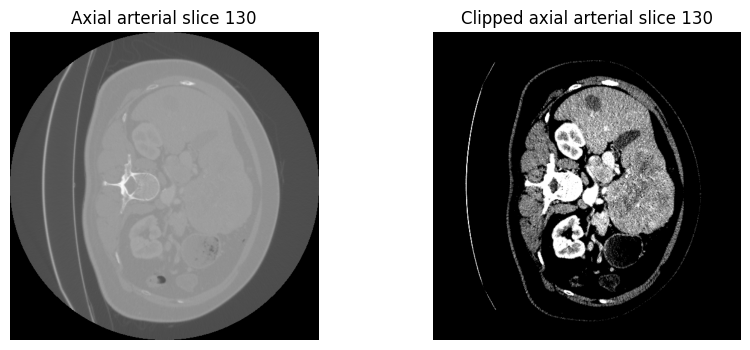

In [16]:
slice = 130
A_img = images[0]
P_img = images[1]


def window_ct(img, center=50, width=150):
    low = center - width / 2
    high = center + width / 2
    return img.clip(low, high)


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(A_img[0, :, :, slice], cmap="gray")
plt.title(f"Axial arterial slice {slice}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(window_ct(A_img[0, :, :, slice]), cmap="gray")
plt.title(f"Clipped axial arterial slice {slice}")
plt.axis("off")

plt.show()

In [17]:
def show_slices(z=130, clipped=True, low=50, high=150):
    plt.figure(figsize=(12,6))
    
    # First image
    plt.subplot(1,2,1)
    img1 = window_ct(A_img[0, :, :, z], low, high) if clipped else A_img[0, :, :, z]
    plt.imshow(img1, cmap="gray")
    plt.title(f"Arterial Slice {z}")
    plt.axis("off")
    
    # Second image
    plt.subplot(1,2,2)
    img2 = window_ct(P_img[0, :, :, z], low, high) if clipped else P_img[0, :, :, z]
    plt.imshow(img2, cmap="gray")
    plt.title(f"Portal Slice {z}")
    plt.axis("off")

# Shared slice slider
widgets.interact(
    show_slices,
    z=(0, A_img.shape[3]-1),
    clipped=True,
    low=(-100,100),
    high=(0,400)
)

interactive(children=(IntSlider(value=130, description='z', max=174), Checkbox(value=True, description='clippe…

<function __main__.show_slices(z=130, clipped=True, low=50, high=150)>

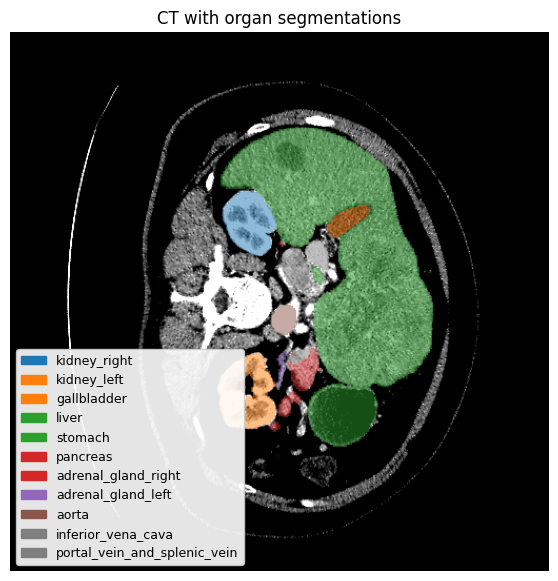

In [22]:
plt.figure(figsize=(7, 7))
plt.imshow(window_ct(A_img[0, :, :, slice]), cmap="gray")

colors = plt.get_cmap("tab10", len(ORGANS))
legend_patches = []

organ_names = list(ORGANS.keys())

for i, organ_name in enumerate(organ_names):
    mask = segments[0][i, :, :, slice]

    if mask.sum() == 0:
        continue

    color = colors(i)
    rgba = np.zeros((*mask.shape, 4))
    rgba[..., :3] = color[:3]
    rgba[..., 3] = mask * 0.5  # transparency only where mask==1

    plt.imshow(rgba)

    legend_patches.append(
        Patch(color=color[:34], label=organ_name)
    )

plt.legend(
    handles=legend_patches,
    loc="lower left",
    framealpha=0.9,
    fontsize=9
)

plt.title("CT with organ segmentations")
plt.axis("off")
plt.show()

### Radiomics Features

In [23]:
import SimpleITK as sitk
from radiomics.firstorder import RadiomicsFirstOrder

In [24]:
mask = segments[0][1, :, :, :] # aorta mask
print(np.unique(mask))
print(mask.shape)
print(A_img[0].shape)
print(mask.sum())



[0 1]
(512, 512, 175)
(512, 512, 175)
71244


In [26]:
image_sitk = sitk.GetImageFromArray(A_img[0])          # Remove channel
mask_sitk = sitk.GetImageFromArray(mask.astype(np.uint8))

firstorder = RadiomicsFirstOrder(image_sitk, mask_sitk)

firstorder.enableAllFeatures()
results = firstorder.execute()
for k, v in results.items():
    print(f"{k}: {v}")

# # Initialize extractor
# extractor = RadiomicsFeatureExtractor()

# # Enable only first-order features (optional)
# extractor.disableAllFeatures()
# extractor.enableFeatureClassByName('firstorder')

# # Compute features
# result = extractor.execute(image_sitk, mask_sitk)

# # Print results
# for k, v in result.items():
#     print(k, v)

10Percentile: 42.0
90Percentile: 160.0
Energy: 991857534.0
Entropy: 2.9242589902845015
InterquartileRange: 72.0
Kurtosis: 3.7896906984076506
Maximum: 254.0
MeanAbsoluteDeviation: 40.20674604132668
Mean: 107.07321318286452
Median: 118.0
Minimum: -153.0
Range: 407.0
RobustMeanAbsoluteDeviation: 28.97921912185206
RootMeanSquared: 117.9914398250535
Skewness: -0.8605783532239104
TotalEnergy: 991857534.0
Uniformity: 0.15820869352784556
Variance: 2457.306890686067


### Feature Selection